## ACO (Ant Colony Optimization)

**Descripción:**
El Ant Colony Optimization (ACO) es un algoritmo bioinspirado basado en el comportamiento de las colonias de hormigas al buscar el camino más corto entre su nido y una fuente de alimento. Se fundamenta en la simulación del rastro de feromonas, una sustancia química que las hormigas depositan en su camino y que guía a otras hormigas hacia soluciones óptimas.

En el contexto de optimización, ACO se emplea para resolver problemas combinatorios complejos, como el Problema del Viajante de Comercio (TSP) o la optimización de rutas. Funciona mediante un sistema de hormigas artificiales que exploran diferentes soluciones y refuerzan los mejores caminos con mayor cantidad de feromonas, lo que conduce a una convergencia hacia soluciones eficientes.

**Este algoritmo puede ser implementado tanto para un objetivo como para multiobjetivo**

Podemos ver el algoritmo ACO implementado en python en el siguiente código:

In [1]:
import numpy as np

def ant_colony_optimization(func_obj, bounds, n_ants, n_iterations, alpha, beta, rho, q):
    """
    Algoritmo de Optimización de Colonia de Hormigas (ACO) sin POO.
    """
    n_dimensions = len(bounds)
    pheromone = np.ones((n_ants, n_dimensions)) * 0.1  # Feromona inicial baja
    best_solution = None
    best_value = np.inf
    
    for iteration in range(n_iterations):
        solutions = np.zeros((n_ants, n_dimensions))
        values = np.zeros(n_ants)
        
        for ant in range(n_ants):
            for dim in range(n_dimensions):
                mu = np.mean(pheromone[:, dim])  # Media de la feromona en la dimensión
                sigma = np.std(pheromone[:, dim]) + 1e-6  # Evitar sigma=0
                solutions[ant, dim] = np.clip(np.random.normal(mu, sigma), bounds[dim][0], bounds[dim][1])
            
            values[ant] = func_obj(solutions[ant])
            if values[ant] < best_value:
                best_value = values[ant]
                best_solution = solutions[ant].copy()
        
        pheromone = update_pheromone(pheromone, solutions, values, rho, q, n_ants)
    
    return best_solution, best_value

def update_pheromone(pheromone, solutions, values, rho, q, n_ants):
    """ Actualiza la feromona considerando solo las mejores hormigas """
    pheromone *= (1 - rho)  # Evaporación de la feromona
    
    sorted_indices = np.argsort(values)
    for i in range(n_ants // 2):  # Refuerzo solo con las mejores hormigas
        pheromone[i] += q / (1 + values[sorted_indices[i]])
    
    return pheromone

# Función objetivo de Rastrigin
def rastrigin(x):
    A = 10
    return A * len(x) + np.sum(x**2 - A * np.cos(2 * np.pi * x))

# Límites de búsqueda para cada dimensión
bounds = [(-5.12, 5.12)] * 5  # 5 dimensiones

# Ejecutar la optimización de colonia de hormigas
best_solution, best_value = ant_colony_optimization(rastrigin, bounds, n_ants=30, n_iterations=100, alpha=1.0, beta=2.0, rho=0.5, q=1.0)

print(f"Mejor solución: {best_solution}")
print(f"Valor de la función objetivo: {best_value}")

Mejor solución: [ 0.04137635 -0.0054821   0.04361814  0.01684006  0.01397873]
Valor de la función objetivo: 0.8137663533995934


## Parámetros del Algoritmo de Colonia de Hormigas

En general, estos parámetros deben equilibrarse para encontrar un buen compromiso entre **exploración** y **explotación** en la búsqueda de soluciones óptimas.

- **Exploración**: Proceso de búsqueda de nuevas rutas o soluciones, favoreciendo la diversidad de opciones.
- **Explotación**: Proceso de refinamiento de las soluciones ya conocidas, favoreciendo la búsqueda en áreas prometedoras.

### **func_obj (Función objetivo)**
- **Descripción**: Función que se busca minimizar. Representa la medida de calidad de las soluciones.
- **Aumentar**: Una función más compleja o con más dimensiones puede mejorar la precisión de la optimización.
- **Disminuir**: Funciones más simples pueden acelerar la convergencia, pero pueden no capturar la complejidad de los problemas reales.

### **bounds (Límites de cada dimensión)**
- **Descripción**: Los límites para cada dimensión del espacio de búsqueda.
- **Aumentar**: Ampliar los límites puede aumentar la diversidad de soluciones, pero hace que la búsqueda sea más compleja.
- **Disminuir**: Limitar los límites puede reducir la complejidad de la optimización, pero también puede restringir el espacio de búsqueda.

### **n_ants (Número de hormigas)**
- **Descripción**: Cantidad de hormigas simuladas en cada iteración. Cada hormiga construye una solución.
- **Aumentar**: Mejora la exploración del espacio de soluciones, pero incrementa el tiempo de ejecución.
- **Disminuir**: Reduce el tiempo de ejecución, pero puede llevar a soluciones subóptimas debido a la menor exploración.

### **n_iterations (Número de iteraciones)**
- **Descripción**: Número de ciclos en los que se ejecuta el algoritmo.
- **Aumentar**: Puede mejorar la calidad de la solución al permitir más refinamiento, pero aumenta el tiempo de ejecución.
- **Disminuir**: Reduce el tiempo de ejecución, pero puede detener la optimización antes de encontrar una buena solución.

### **alpha (Importancia de la feromona en la decisión de la hormiga)**
- **Descripción**: Controla cuánto influye la cantidad de feromona en la elección del siguiente punto.
- **Aumentar**: Hace que las hormigas sigan más las rutas con más feromonas, lo que puede llevar a una convergencia prematura.
- **Disminuir**: Aumenta la exploración de nuevas rutas al reducir la influencia de las feromonas.

### **beta (Importancia de la distancia en la decisión de la hormiga)**
- **Descripción**: Controla cuánto influye la distancia en la elección del siguiente punto.
- **Aumentar**: Favorece caminos más cortos, reduciendo la probabilidad de que la feromona influya demasiado en la decisión.
- **Disminuir**: Reduce la importancia de la distancia y hace que las hormigas sigan más las rutas con más feromonas.

### **rho (Tasa de evaporación de la feromona)**
- **Descripción**: Factor por el cual se multiplica la matriz de feromonas en cada iteración, simulando la evaporación.
- **Aumentar**: Hace que la feromona desaparezca más rápido, promoviendo la exploración y evitando que una sola ruta domine demasiado pronto.
- **Disminuir**: Mantiene la feromona por más tiempo, lo que puede acelerar la convergencia pero también llevar a un estancamiento en soluciones subóptimas.

### **Q (Cantidad de feromona depositada en cada recorrido)**
- **Descripción**: Controla la cantidad de feromona depositada en cada camino según su calidad.
- **Aumentar**: Hace que las diferencias entre rutas buenas y malas sean más notables, acelerando la convergencia.
- **Disminuir**: Reduce la intensidad de la actualización de feromonas, fomentando la exploración pero ralentizando la convergencia.

### **q0 (Probabilidad de explotación vs exploración)**
- **Descripción**: Determina el balance entre explotación y exploración. Si es alto, las hormigas tienden a explotar más las soluciones con feromona alta.
- **Aumentar**: Favorece la explotación, lo que puede llevar a una rápida convergencia, pero puede estancarse en óptimos locales.
- **Disminuir**: Favorece la exploración, lo que permite encontrar nuevas soluciones, pero ralentiza la convergencia.


El problema del viajante de comercio (TSP) es un problema clásico de optimización combinatoria en el que un viajante debe visitar un conjunto de ciudades exactamente una vez y regresar a la ciudad de origen, minimizando la distancia total recorrida. Se trata de un problema NP-difícil, lo que significa que no existe un algoritmo exacto eficiente para resolverlo en todos los casos, especialmente cuando el número de ciudades es grande.


### **Resolución de TSP con ACO**
**Principio:** Se basa en el comportamiento de las hormigas al encontrar caminos entre su colonia y una fuente de alimento. Las hormigas depositan feromonas en los caminos más cortos, reforzando su uso en iteraciones futuras.  

**Cómo resuelve el TSP:**  
1. Se representa el problema con una red de ciudades conectadas por caminos con feromonas.  
2. Cada hormiga comienza en una ciudad y construye una ruta siguiendo una política de probabilidad basada en:  
   - La cantidad de feromona en un camino (más feromona → mayor probabilidad de elección).  
   - La distancia entre ciudades (preferencia por caminos más cortos).  
3. Una vez que todas las hormigas han construido sus rutas, las mejores soluciones refuerzan los caminos más prometedores mediante un incremento de feromona.  
4. La feromona se evapora con el tiempo para evitar estancamiento en soluciones locales.  
5. Se repiten iteraciones hasta alcanzar una solución óptima o cumplir un criterio de parada.  

✅ **Ventajas:**  
- Explora múltiples rutas simultáneamente.  
- Equilibra exploración y explotación mediante la evaporación de feromonas.  

❌ **Desventajas:**  
- Puede converger prematuramente a una solución subóptima.  
- Dependiente de los parámetros iniciales.  

---

Hay que tener en cuenta que este problema es de un solo objetivo (single-objective), ya que solo se busca minimizar la distancia total recorrida. Por lo tanto, el ACO implementado para resolver este problema será una optimización de un solo objetivo.

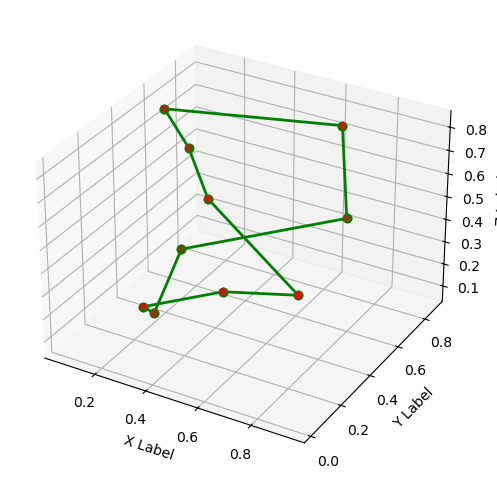

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def distance(point1, point2):
    return np.sqrt(np.sum((point1 - point2)**2))

def ant_colony_optimization_tsp(points, n_ants, n_iterations, alpha, beta, evaporation_rate, Q):
    n_points = len(points)
    pheromone = np.ones((n_points, n_points))
    best_path = None
    best_path_length = np.inf

    for iteration in range(n_iterations):
        paths = []
        path_lengths = []

        for ant in range(n_ants):
            visited = [False]*n_points
            current_point = np.random.randint(n_points)
            visited[current_point] = True
            path = [current_point]
            path_length = 0

            while False in visited:
                unvisited = np.where(np.logical_not(visited))[0]
                probabilities = np.zeros(len(unvisited))

                for i, unvisited_point in enumerate(unvisited):
                    probabilities[i] = pheromone[current_point, unvisited_point]**alpha / distance(points[current_point], points[unvisited_point])**beta

                probabilities /= np.sum(probabilities)

                next_point = np.random.choice(unvisited, p=probabilities)
                path.append(next_point)
                path_length += distance(points[current_point], points[next_point])
                visited[next_point] = True
                current_point = next_point

            paths.append(path)
            path_lengths.append(path_length)

            if path_length < best_path_length:
                best_path = path
                best_path_length = path_length

        pheromone *= evaporation_rate

        for path, path_length in zip(paths, path_lengths):
            for i in range(n_points-1):
                pheromone[path[i], path[i+1]] += Q/path_length
            pheromone[path[-1], path[0]] += Q/path_length

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(points[:,0], points[:,1], points[:,2], c='r', marker='o')

    for i in range(n_points-1):
        ax.plot([points[best_path[i],0], points[best_path[i+1],0]],
                [points[best_path[i],1], points[best_path[i+1],1]],
                [points[best_path[i],2], points[best_path[i+1],2]],
                c='g', linestyle='-', linewidth=2, marker='o')

    ax.plot([points[best_path[0],0], points[best_path[-1],0]],
            [points[best_path[0],1], points[best_path[-1],1]],
            [points[best_path[0],2], points[best_path[-1],2]],
            c='g', linestyle='-', linewidth=2, marker='o')

    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')
    ax.set_zlabel('Z Label')
    plt.show()

# Example usage:
points = np.random.rand(10, 3) # Generate 10 random 3D points
ant_colony_optimization_tsp(points, n_ants=10, n_iterations=100, alpha=1, beta=1, evaporation_rate=0.5, Q=1)

## Exploración: 
Para priorizar la exploración en el algoritmo de optimización por colonia de hormigas (ACO), debemos: 
- Reducir α (importancia de las feromonas): Esto hará que las hormigas dependan menos de las feromonas y exploren más aleatoriamente. 
- Aumentar β (importancia de la heurística de distancia): Esto hace que las hormigas prefieran caminos más cortos, reduciendo la influencia de las feromonas. 
- Aumentar la tasa de evaporación: Un valor más alto para evaporation_rate significa que las feromonas se desvanecen más rápido, evitando que las hormigas se queden atrapadas en un solo camino. 
- Aumentar el número de hormigas: Más hormigas recorriendo el espacio amplían la exploración.

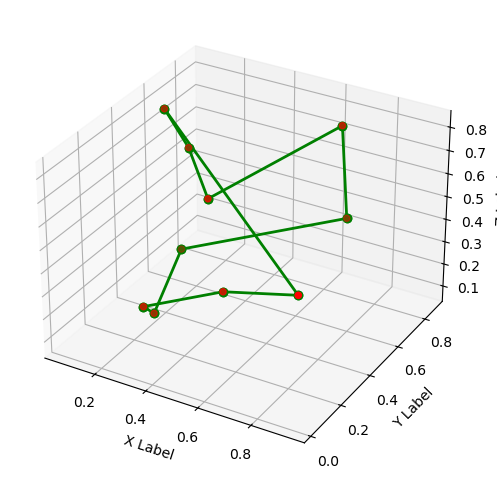

In [3]:
ant_colony_optimization_tsp(points, n_ants=20, n_iterations=100, alpha=0.5, beta=2, evaporation_rate=0.8, Q=1)

## Explotación: 
Para priorizar la explotación en el algoritmo de optimización por colonia de hormigas (ACO): 
- Aumentar α (importancia de las feromonas): Las hormigas seguirán más los caminos que ya han sido reforzados. 
- Reducir β (importancia de la heurística de distancia): Disminuye la influencia de la distancia y favorece la explotación de caminos con más feromonas. 
- Reducir la tasa de evaporación: Menos evaporación significa que las feromonas persisten más tiempo, reforzando caminos anteriores. 
- Reducir el número de hormigas: Menos hormigas significa menos exploración y más dependencia de los caminos ya descubiertos.

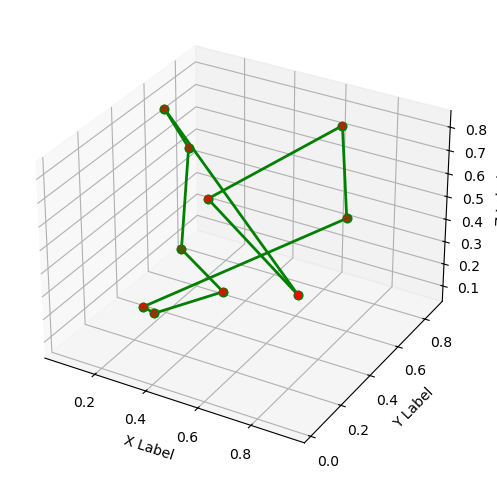

In [4]:
ant_colony_optimization_tsp(points, n_ants=5, n_iterations=100, alpha=3, beta=0.5, evaporation_rate=0.2, Q=1)

# Funciones de Optimización

Las funciones de optimización son herramientas fundamentales en el campo de la inteligencia artificial, el aprendizaje automático y la investigación operativa. Estas funciones se utilizan para evaluar el rendimiento de algoritmos de optimización y ayudar en el desarrollo de métodos más eficientes. En particular, las **funciones de prueba para optimización** ([Test Functions for Optimization](https://en.wikipedia.org/wiki/Test_functions_for_optimization)) permiten analizar el comportamiento de diferentes algoritmos en la búsqueda de soluciones óptimas.

Una función de optimización puede ser de **un solo objetivo** o **multiobjetivo**. En el caso de las funciones de un solo objetivo, el objetivo es encontrar un mínimo o un máximo único dentro de un espacio de búsqueda definido. Estas funciones se usan comúnmente para evaluar la eficacia de algoritmos metaheurísticos.

## Función de Rastrigin

La **función de Rastrigin** es una de las funciones de prueba más utilizadas de **un solo objetivo** en optimización. Su expresión matemática en \( n \) dimensiones es:

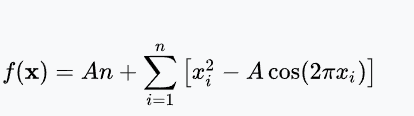

donde \( x_i \) está definido en el rango \( [-5.12, 5.12] \). La función tiene un mínimo global en \( x = 0 \), donde \( f(0) = 0 \), pero su superficie contiene múltiples óptimos locales, lo que la hace un desafío para los algoritmos de optimización.

## Aplicación de la Función de Rastrigin en un Algoritmo de Colonia de Hormigas

En el siguiente código veremos el desempeño de ACO para resolver esta función que tiene como mínimo global: 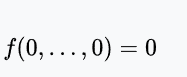
Por lo tanto al aplicar ACO con n = 5 debería converger a [0,0,0,0,0].


In [5]:
# Función objetivo de Rastrigin
def rastrigin(x):
    A = 10
    return A * len(x) + np.sum(x**2 - A * np.cos(2 * np.pi * x))

# Límites de búsqueda para cada dimensión
bounds = [(-5.12, 5.12)] * 5

# Ejecutar la optimización de colonia de hormigas
best_solution, best_value = ant_colony_optimization(
    rastrigin,
    bounds,
    n_ants=30,
    n_iterations=100,
    alpha=1.0,
    beta=2.0,
    rho=0.5,
    q=1.0
)


print(f"Mejor solución: {best_solution}")
print(f"Valor de la función objetivo: {best_value}")

Mejor solución: [-0.02878925 -0.01115987  0.01424563  0.01471098 -0.01431481]
Valor de la función objetivo: 0.31244882487536074


## Exploración (Mayor diversidad de soluciones) 
- Baja influencia de feromonas → alpha = 0.5 
- Alta importancia de heurística → beta = 3.0 
- Alta evaporación de feromonas → rho = 0.8 (menor memoria, fomenta exploración)

In [6]:
best_solution_exploration, best_value_exploration = ant_colony_optimization(
    rastrigin,
    bounds,
    n_ants=30,
    n_iterations=100,
    alpha=0.5,  # Baja influencia de feromonas (más exploración)
    beta=3.0,   # Alta importancia de la heurística
    rho=0.8,    # Alta evaporación (menos memoria, más exploración)
    q=1.0
)

print(f"[Exploración] Mejor solución: {best_solution_exploration}")
print(f"[Exploración] Valor de la función objetivo: {best_value_exploration}")


[Exploración] Mejor solución: [-0.00944024 -0.00479281  0.02019499  0.0326947  -0.0076302 ]
[Exploración] Valor de la función objetivo: 0.325913004198938


## Explotación (Mayor precisión y convergencia) 
- Alta influencia de feromonas → alpha = 2.0
- Baja importancia de heurística → beta = 1.0 
- Baja evaporación de feromonas → rho = 0.2 (más memoria, menos exploración)

In [7]:
best_solution_exploitation, best_value_exploitation = ant_colony_optimization(
    rastrigin,
    bounds,
    n_ants=30,
    n_iterations=100,
    alpha=2.0,  # Alta influencia de feromonas (más explotación)
    beta=1.0,   # Baja importancia de la heurística
    rho=0.2,    # Baja evaporación (mayor persistencia de memoria)
    q=1.0
)

print(f"[Explotación] Mejor solución: {best_solution_exploitation}")
print(f"[Explotación] Valor de la función objetivo: {best_value_exploitation}")

[Explotación] Mejor solución: [-0.00414293  0.07571396  0.02558542 -0.00461327  0.00311419]
[Explotación] Valor de la función objetivo: 1.2552658019446383


## Función de Schaffer N
La **función de Schaffer N** es otra de las funciones de test para optimizar algoritmos y tiene la forma: 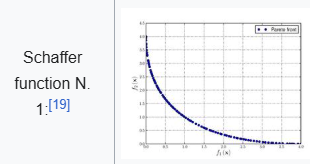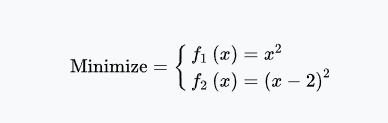

## Aplicación de la Función de Schaffer N (Multiobjetivo) en un Algoritmo de Colonia de Hormigas

In [8]:
# Funciones objetivo
def f1(x):
    return x[0]**2

def f2(x):
    return (x[0] - 2)**2

# Función combinada (escala ambas funciones en una sola)
def combined_objective(x, w1=0.5, w2=0.5):
    return w1 * f1(x) + w2 * f2(x)

# Límites de búsqueda
bounds = [(-2, 4)]  # Solo una dimensión en este problema

# Ejecutar la optimización con la función combinada
best_solution, best_value = ant_colony_optimization(combined_objective, bounds, n_ants=30, n_iterations=100, alpha=1.0, beta=2.0, rho=0.5, q=1.0)

print(f"Mejor solución encontrada: {best_solution}")
print(f"Valor de la función objetivo combinada: {best_value}")

Mejor solución encontrada: [1.00011102]
Valor de la función objetivo combinada: 1.000000012325226


## Exploracion: 

In [9]:
best_solution_exploration, best_value_exploration = ant_colony_optimization(
    combined_objective,
    bounds,
    n_ants=30,
    n_iterations=100,
    alpha=0.5,    # Baja influencia de feromonas (mayor exploración)
    beta=3.0,     # Alta importancia de heurística
    rho=0.8,      # Alta evaporación (menos memoria)
    q=1.0
)

print(f"[Exploración] Mejor solución encontrada: {best_solution_exploration}")
print(f"[Exploración] Valor de la función objetivo combinada: {best_value_exploration}")

[Exploración] Mejor solución encontrada: [1.01342814]
[Exploración] Valor de la función objetivo combinada: 1.0001803149252844


## Explotación: 

In [10]:
best_solution_exploitation, best_value_exploitation = ant_colony_optimization(
    combined_objective,
    bounds,
    n_ants=30,
    n_iterations=100,
    alpha=2.0,    # Alta influencia de feromonas (fuerza convergencia)
    beta=1.0,     # Baja importancia de heurística
    rho=0.2,      # Baja evaporación (memoria persistente)
    q=1.0
)

print(f"[Explotación] Mejor solución encontrada: {best_solution_exploitation}")
print(f"[Explotación] Valor de la función objetivo combinada: {best_value_exploitation}")

[Explotación] Mejor solución encontrada: [1.00031967]
[Explotación] Valor de la función objetivo combinada: 1.000000102188359


## Función de Rosenbrock restringida a un disco
La **función de Rosenbrock restringida a un disco** tiene la siguiente forma: 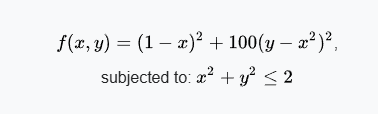 y su mínimo global es: 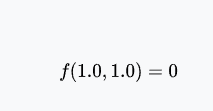

## Aplicación de la Función de Rosenbrock en un Algoritmo de Colonia de Hormigas

In [11]:
def rosenbrock(x):
    return (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2

# Función de penalización para restringir la solución al disco
def penalty(x, radius=2.0):
    if np.sum(x**2) > radius**2:
        return np.sum(x**2) - radius**2  # Penaliza por estar fuera del disco
    return 0

# Límites de búsqueda para cada dimensión
bounds = [(-np.sqrt(2), np.sqrt(2))] * 2  # 2 dimensiones con límites para el disco de radio 2

# Ejecutar la optimización de colonia de hormigas con la función de Rosenbrock y la restricción del disco
best_solution, best_value = ant_colony_optimization(rosenbrock, bounds, n_ants=30, n_iterations=100, alpha=1.0, beta=2.0, rho=0.5, q=1.0)

print(f"Mejor solución: {best_solution}")
print(f"Valor de la función objetivo: {best_value}")

Mejor solución: [1.01532587 1.02832784]
Valor de la función objetivo: 0.0008896235367513635


## Exploración vs Explotación

In [12]:
best_solution_exploration, best_value_exploration = ant_colony_optimization(
    rosenbrock,
    bounds,
    n_ants=30,
    n_iterations=100,
    alpha=0.5,  # Baja influencia de feromonas (mayor exploración)
    beta=3.0,   # Alta importancia heurística
    rho=0.8,    # Alta evaporación (menos memoria, más exploración)
    q=1.0
)

print(f"[Exploración] Mejor solución: {best_solution_exploration}")
print(f"[Exploración] Valor de la función objetivo: {best_value_exploration}")

best_solution_exploitation, best_value_exploitation = ant_colony_optimization(
    rosenbrock,
    bounds,
    n_ants=30,
    n_iterations=100,
    alpha=2.0,  # Alta influencia de feromonas (más explotación)
    beta=1.0,   # Baja importancia heurística
    rho=0.2,    # Baja evaporación (mayor persistencia de memoria)
    q=1.0
)

print(f"[Explotación] Mejor solución: {best_solution_exploitation}")
print(f"[Explotación] Valor de la función objetivo: {best_value_exploitation}")

[Exploración] Mejor solución: [0.88305366 0.7823783 ]
[Exploración] Valor de la función objetivo: 0.014349613895256857
[Explotación] Mejor solución: [0.92253175 0.84318174]
[Explotación] Valor de la función objetivo: 0.012215639067506869
